In [2]:
import pandas as pd
df = pd.read_csv('./AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.407747,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.386473,43971200.0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.358108,26432000.0
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366972,21610400.0
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.377609,18362400.0


In [3]:
#getting an idea about the data\
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9823 entries, 0 to 9822
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9823 non-null   str    
 1   Open       9822 non-null   float64
 2   High       9822 non-null   float64
 3   Low        9822 non-null   float64
 4   Close      9822 non-null   float64
 5   Adj Close  9822 non-null   float64
 6   Volume     9822 non-null   float64
dtypes: float64(6), str(1)
memory usage: 537.3 KB


In [4]:
df.shape

(9823, 7)

In [5]:
#check for missing values
print(df.isnull().sum())

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64


In [6]:
#drop missing values
df = df.dropna()

In [7]:
print(df.shape)
print(df.isnull().sum())

(9822, 7)
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [8]:
#fix date column
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
#set date as index
df.set_index('Date', inplace=True)

In [10]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 9822 entries, 1980-12-12 to 2019-11-25
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       9822 non-null   float64
 1   High       9822 non-null   float64
 2   Low        9822 non-null   float64
 3   Close      9822 non-null   float64
 4   Adj Close  9822 non-null   float64
 5   Volume     9822 non-null   float64
dtypes: float64(6)
memory usage: 537.1 KB
None
                Open      High       Low     Close  Adj Close       Volume
Date                                                                      
1980-12-12  0.513393  0.515625  0.513393  0.513393   0.407747  117258400.0
1980-12-15  0.488839  0.488839  0.486607  0.486607   0.386473   43971200.0
1980-12-16  0.453125  0.453125  0.450893  0.450893   0.358108   26432000.0
1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366972   21610400.0
1980-12-18  0.475446  0.477679  0.475446  0.475446   0.377609   183624

# SCALING

In [11]:
data = df[['Adj Close']]

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [13]:
print(scaled_data[:5])

[[0.00094304]
 [0.00086335]
 [0.00075709]
 [0.00079029]
 [0.00083014]]


# Sequence creation

In [14]:
import numpy as np

X = []
y = []

window_size = 60

In [15]:
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i])

In [16]:
X = np.array(X)
y = np.array(y)

In [17]:
print(X.shape)
print(y.shape)

(9762, 60, 1)
(9762, 1)


# Train Test Split

In [18]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(7809, 60, 1)
(1953, 60, 1)


# Model Building

## RNN

In [19]:
#importing libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [20]:
model_rnn = Sequential()

model_rnn.add(SimpleRNN(50, input_shape=(60,1)))
model_rnn.add(Dropout(0.2))
model_rnn.add(Dense(1))

model_rnn.compile(optimizer='adam', loss='mse')

c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3
)

checkpoint = ModelCheckpoint(
    'best_rnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [22]:
history = model_rnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 1.4026e-04 - val_loss: 0.0154
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.1446e-05 - val_loss: 0.0046
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2.6633e-05 - val_loss: 0.0026
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.5378e-05 - val_loss: 0.0011
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 2.1672e-05 - val_loss: 0.0014
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.2537e-05 - val_loss: 0.0014
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.7192e-05 - val_loss: 0.0013


In [23]:
y_pred = model_rnn.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [24]:
y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)

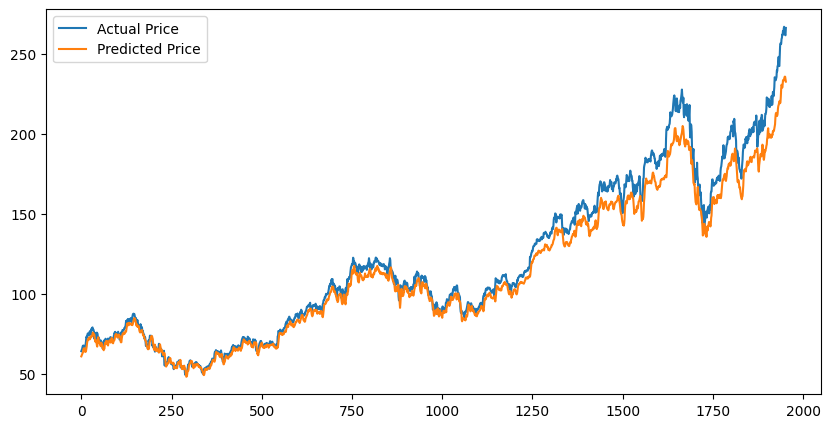

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.legend()
plt.show()

## LSTM

In [26]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential()

model_lstm.add(LSTM(50, input_shape=(60,1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 1.3649e-04 - val_loss: 7.5806e-04
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 2.1773e-05 - val_loss: 0.0014
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 1.7791e-05 - val_loss: 2.5535e-04
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 1.8780e-05 - val_loss: 4.9972e-04
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 1.5262e-05 - val_loss: 2.5471e-04
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 1.4664e-05 - val_loss: 1.7840e-04
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1.3873e-05 - val_loss: 1.6453e-04
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 1.4097e-05 - val_loss: 8.0367e-04
Epoch 9/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 1.3829e-05 - val_loss: 2.0121e-04
Epoch 10/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 1.4241e-05 - val_loss: 1.5510e-04


In [28]:
y_pred_lstm = model_lstm.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [29]:
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_actual = scaler.inverse_transform(y_test)

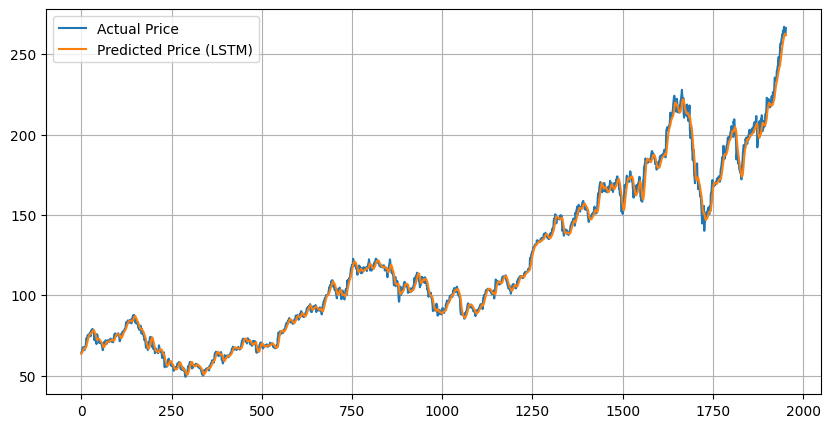

In [30]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(y_pred_lstm, label='Predicted Price (LSTM)')

plt.legend()
plt.grid()

plt.show()

In [31]:
#calculate mean squared error
from sklearn.metrics import mean_squared_error

mse_lstm = mean_squared_error(y_test_actual, y_pred_lstm)
print("LSTM MSE:", mse_lstm)

LSTM MSE: 11.052026483135556


## MULTI-STEP PREDICTION

In [32]:
#function to create sequences
def create_sequences_multi(data, window_size, future_steps):
    X, y = [], []

    for i in range(window_size, len(data) - future_steps + 1):
        X.append(data[i-window_size:i])
        y.append(data[i:i+future_steps])

    return np.array(X), np.array(y)

In [33]:
#create datasets
window_size = 60

# 5-day prediction
X5, y5 = create_sequences_multi(scaled_data, window_size, 5)

# 10-day prediction
X10, y10 = create_sequences_multi(scaled_data, window_size, 10)

print(X5.shape, y5.shape)
print(X10.shape, y10.shape)

(9758, 60, 1) (9758, 5, 1)
(9753, 60, 1) (9753, 10, 1)


In [34]:
y5 = y5.reshape(y5.shape[0], y5.shape[1])
y10 = y10.reshape(y10.shape[0], y10.shape[1])

In [35]:
print(y5.shape)
print(y10.shape)

(9758, 5)
(9753, 10)


In [36]:
#train test split
split5 = int(0.8 * len(X5))
X5_train, X5_test = X5[:split5], X5[split5:]
y5_train, y5_test = y5[:split5], y5[split5:]

split10 = int(0.8 * len(X10))
X10_train, X10_test = X10[:split10], X10[split10:]
y10_train, y10_test = y10[:split10], y10[split10:]

In [37]:
# for 5 day
model_lstm_5 = Sequential()

model_lstm_5.add(LSTM(50, input_shape=(60,1)))
model_lstm_5.add(Dropout(0.2))
model_lstm_5.add(Dense(5))  

model_lstm_5.compile(optimizer='adam', loss='mse')

c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
## for 10 day
model_lstm_10 = Sequential()

model_lstm_10.add(LSTM(50, input_shape=(60,1)))
model_lstm_10.add(Dropout(0.2))
model_lstm_10.add(Dense(10))  # ← IMPORTANT

model_lstm_10.compile(optimizer='adam', loss='mse')

In [39]:
#train
model_lstm_5.fit(X5_train, y5_train, epochs=10, batch_size=32)
model_lstm_10.fit(X10_train, y10_train, epochs=10, batch_size=32)

Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 2.8345e-04
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 4.0245e-05
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 3.1776e-05
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 2.9037e-05
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 2.6700e-05
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.2301e-05
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 1.9582e-05
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 1.9619e-05
Epoch 9/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 2.0233e-05
Epoch 10/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.9921e-05
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 1.9847e-04
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 4.9726e-05
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 3.8520e-05
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 3

In [40]:
#predict
y5_pred = model_lstm_5.predict(X5_test)
y10_pred = model_lstm_10.predict(X10_test)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [41]:
y5_pred = scaler.inverse_transform(y5_pred)
y5_test_actual = scaler.inverse_transform(y5_test)

y10_pred = scaler.inverse_transform(y10_pred)
y10_test_actual = scaler.inverse_transform(y10_test)

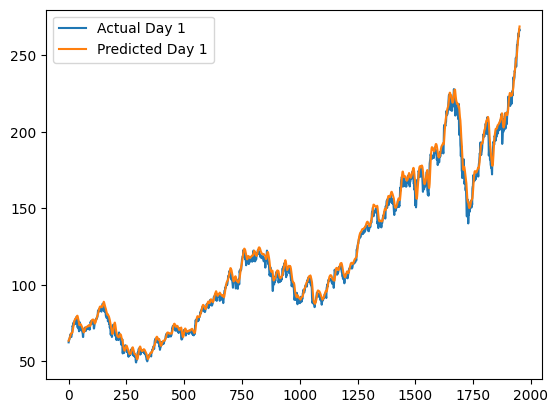

In [42]:
plt.plot(y5_test_actual[:,0], label="Actual Day 1")
plt.plot(y5_pred[:,0], label="Predicted Day 1")
plt.legend()
plt.show()

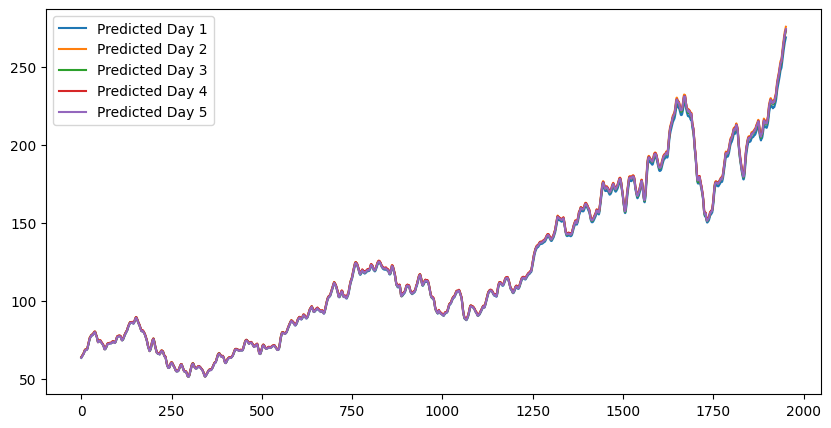

In [43]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.plot(y5_pred[:,i], label=f'Predicted Day {i+1}')

plt.legend()
plt.show()

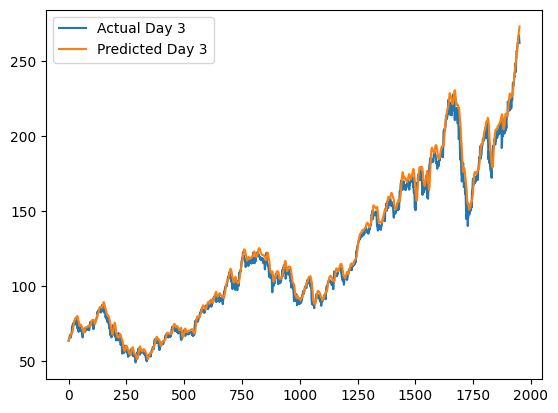

In [44]:
plt.plot(y5_test_actual[:,2], label="Actual Day 3")
plt.plot(y5_pred[:,2], label="Predicted Day 3")
plt.legend()
plt.show()

In [46]:
#RNN for 5 day
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model_rnn_5 = Sequential()

model_rnn_5.add(SimpleRNN(50, input_shape=(60,1)))
model_rnn_5.add(Dropout(0.2))
model_rnn_5.add(Dense(5))  

model_rnn_5.compile(optimizer='adam', loss='mse')

In [47]:
model_rnn_5.fit(X5_train, y5_train, epochs=10, batch_size=32)

Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 3.1143e-04
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.3660e-05
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.8800e-05
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5.4276e-05
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.9476e-05
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.2899e-05
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.5852e-05
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.2724e-05
Epoch 9/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.3092e-05
Epoch 10/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.2503e-05


In [48]:
y5_pred_rnn = model_rnn_5.predict(X5_test)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [50]:
y5_pred_rnn = scaler.inverse_transform(y5_pred_rnn)
y5_test_actual = scaler.inverse_transform(y5_test)

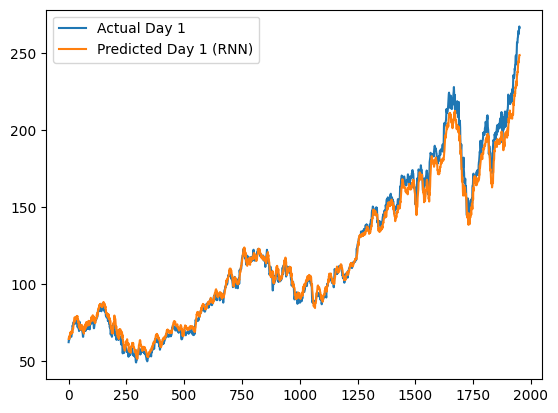

In [51]:
import matplotlib.pyplot as plt

plt.plot(y5_test_actual[:,0], label="Actual Day 1")
plt.plot(y5_pred_rnn[:,0], label="Predicted Day 1 (RNN)")
plt.legend()
plt.show()

In [54]:
#rnn for 10 day
model_rnn_10 = Sequential()

model_rnn_10.add(SimpleRNN(50, input_shape=(60,1)))
model_rnn_10.add(Dropout(0.2))
model_rnn_10.add(Dense(10))  

model_rnn_10.compile(optimizer='adam', loss='mse')

In [55]:
model_rnn_10.fit(X10_train, y10_train, epochs=10, batch_size=32)

Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.9366e-04
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 7.1649e-05
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5.1332e-05
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 4.0889e-05
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.8458e-05
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.1535e-05
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 3.0178e-05
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.4949e-05
Epoch 9/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 2.3763e-05
Epoch 10/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 2.2608e-05


In [56]:
y10_pred_rnn = model_rnn_10.predict(X10_test)

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [57]:
y10_pred_rnn = scaler.inverse_transform(y10_pred_rnn)
y10_test_actual = scaler.inverse_transform(y10_test)

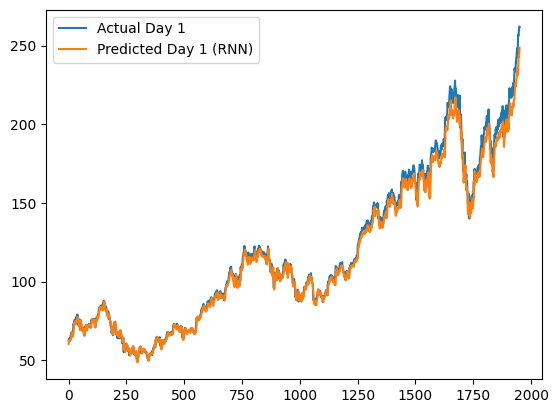

In [58]:
plt.plot(y10_test_actual[:,0], label="Actual Day 1")
plt.plot(y10_pred_rnn[:,0], label="Predicted Day 1 (RNN)")
plt.legend()
plt.show()

In [59]:
from sklearn.metrics import mean_squared_error

mse_rnn_5 = mean_squared_error(y5_test_actual[:,0], y5_pred_rnn[:,0])
mse_rnn_10 = mean_squared_error(y10_test_actual[:,0], y10_pred_rnn[:,0])

print("RNN 5-day MSE:", mse_rnn_5)
print("RNN 10-day MSE:", mse_rnn_10)

RNN 5-day MSE: 34.81034623188568
RNN 10-day MSE: 24.139325199065777
